# Modelagem de Classificação Avançada: Extreme Gradient Boosting (XGBoost)

Este notebook documenta o desenvolvimento, otimização e avaliação de um modelo baseado em comitês sequenciais de árvores de decisão utilizando o algoritmo XGBoost. O objetivo é mapear o potencial de popularidade comercial de obras literárias a partir de seus metadados de pré-lançamento.

Diferente do baseline linear (Regressão Logística) e de abordagens de amostragem paralela (Random Forest), o XGBoost implementa o paradigma de *Boosting*. Ele constrói estimadores fracos de forma sequencial, onde cada nova árvore é parametrizada para minimizar os resíduos de gradiente gerados pelas árvores anteriores. Este comportamento confere ao modelo uma capacidade refinada de capturar interações não-lineares complexas e fronteiras de decisão altamente irregulares.

## 1. Carga, Consolidação e Engenharia de Atributos

Nesta etapa inicial, os conjuntos de dados previamente processados são carregados e unificados através de um cruzamento estrutural (*Inner Merge*). Como os datasets originais compartilham chaves e métricas, implementa-se um protocolo de limpeza pós-merge para eliminar colunas redundantes e normalizar os identificadores.

A engenharia de atributos (*Feature Engineering*) é conduzida em duas frentes:
1. **Frequência Histórica do Autor:** Mapeamento volumétrico de publicações prévias de cada autor no dataset.
2. **Codificação de Variáveis Categóricas (*Dummies*):** Isolamento dos formatos físicos e digitais mais frequentes, agrupando categorias residuais sob o rótulo 'Other'.

In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# 1. Leitura dos artefatos de dados processados
df_generos = pd.read_parquet('../data/processed/books_pivot_mapped.parquet')
df_original = pd.read_parquet('../data/processed/books_clean.parquet')

# 2. Cruzamento estrutural (Inner Merge)
df_class = pd.merge(
    df_original[['title', 'author', 'bookformat', 'pages', 'totalratings']], 
    df_generos, 
    on=['title', 'author'], 
    how='inner'
)

# 2.2 Limpeza pós-merge: Tratamento de colunas redundantes e sufixos gerados pelo merge
df_class = df_class.drop(columns=['pages_y', 'totalratings_y', 'rating'], errors='ignore')
df_class = df_class.rename(columns={'pages_x': 'pages', 'totalratings_x': 'totalratings'})

# 3. Estruturação da Variável Alvo ordinarizada (3 Classes de Popularidade)
def definir_tres_classes(ratings):
    if ratings >= 10000:
        return 1  # Bestseller
    elif ratings >= 1000:
        return 2  # Média Popularidade
    else:
        return 3  # Nicho

df_class['popularity_class'] = df_class['totalratings'].apply(definir_tres_classes)

# 3. Divisão Estratificada
df_train, df_test = train_test_split(
    df_class, 
    test_size=0.2, 
    random_state=42, 
    stratify=df_class['popularity_class']
)

# Criamos cópias para evitar o aviso "SettingWithCopyWarning" do Pandas
df_train = df_train.copy()
df_test = df_test.copy()


# 4. Engenharia de Atributos
# 4.1. Frequência do Autor (Mapeamento de histórico)
autor_frequencia_treino = df_train['author'].value_counts()

df_train['author_frequency'] = df_train['author'].map(autor_frequencia_treino)
# Se um autor aparecer no Teste mas não existir no Treino, o Pandas retorna NaN. Preenchemos com 0.
df_test['author_frequency'] = df_test['author'].map(autor_frequencia_treino).fillna(0)

# 4.2. Tratamento do Formato do Livro (Top 5 extraídos APENAS do Treino)
top_formatos_treino = df_train['bookformat'].value_counts().index[:5]

df_train['format_grouped'] = df_train['bookformat'].apply(lambda x: x if x in top_formatos_treino else 'Other')
df_test['format_grouped'] = df_test['bookformat'].apply(lambda x: x if x in top_formatos_treino else 'Other')

# 4.3. Codificação Categórica (Dummies)
df_formatos_train = pd.get_dummies(df_train['format_grouped'], prefix='format', drop_first=True)
df_formatos_test = pd.get_dummies(df_test['format_grouped'], prefix='format', drop_first=True)

# Alinhamento de segurança: Garante que o teste tenha exatamente as mesmas colunas do treino
df_formatos_test = df_formatos_test.reindex(columns=df_formatos_train.columns, fill_value=0)

# 5. Mapeamento dos macro-gêneros literários consolidados
macro_generos = [
    'Artes, Lazer e Estilo de Vida', 'Fantasia e Ficção Científica', 
    'Ficção Geral e Literatura', 'História e Biografia', 
    'Infantojuvenil e Quadrinhos', 'Mistério, Thriller e Terror', 
    'Não-Ficção e Autodesenvolvimento', 'Outros', 'Romance'
]

# 6. Consolidação Final das Matrizes Preditores (X) e Alvo (y)
x_train = pd.concat([df_train[['pages', 'author_frequency']], df_formatos_train, df_train[macro_generos]], axis=1).astype(float)
y_train = df_train['popularity_class']

x_test = pd.concat([df_test[['pages', 'author_frequency']], df_formatos_test, df_test[macro_generos]], axis=1).astype(float)
y_test = df_test['popularity_class']


## 2. Particionamento de Dados e Prevenção de Data Leakage

Para garantir a capacidade de generalização do classificador, o dataset é segmentado na proporção 80% para treinamento e 20% para teste. 

Utiliza-se o parâmetro `stratify=y` para assegurar que a distribuição original das classes (altamente desbalanceada) seja rigorosamente preservada em ambas as partições. Adicionalmente, implementa-se a padronização por escore-Z (`StandardScaler`). Embora algoritmos baseados em árvores de decisão sejam matematicamente invariantes à escala dos atributos, a manutenção da padronização nesta etapa visa assegurar a consistência do pipeline de dados e a comparabilidade direta com os artefatos dos modelos anteriores.

In [14]:
from sklearn.preprocessing import StandardScaler

# Inicialização do padronizador 
scaler = StandardScaler()

# Ajuste e transformação baseados exclusivamente no treino
x_train_scaled = scaler.fit_transform(x_train)

# Transformação do teste para simular o ambiente produtivo
x_test_scaled = scaler.transform(x_test)

print(f"Dimensões do Conjunto de Treino: {x_train_scaled.shape}")
print(f"Dimensões do Conjunto de Teste: {x_test_scaled.shape}")

Dimensões do Conjunto de Treino: (65604, 16)
Dimensões do Conjunto de Teste: (16402, 16)


## 3. Parametrização e Otimização Hiperparamétrica do Comitê de Boosting

O motor de execução do XGBoost impõe restrições matemáticas específicas que exigem duas adequações metodológicas cruciais:
1. **Alinhamento de Rótulos Multiclasse:** O algoritmo exige indexação baseada em zero. Desse modo, o vetor alvo original $[1, 2, 3]$ é transformado em $[0, 1, 2]$.
2. **Balanceamento Dinâmico de Custo (Sample Weighting):** Como o parâmetro nativo `scale_pos_weight` do XGBoost limita-se a problemas binários, calcula-se o peso específico de cada instância amostral (`compute_sample_weight`). Esses pesos são injetados diretamente na função de perda durante o cálculo do gradiente, forçando o modelo a penalizar os erros cometidos nas classes minoritárias (Bestsellers).

A busca pela combinação ótima de hiperparâmetros é conduzida via `GridSearchCV` acoplado a uma validação cruzada em 5 folds ($k=5$), otimizando a métrica **F1-Macro**.

In [15]:
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import GridSearchCV

# 1. Reindexação estrita das classes para o intervalo [0, 1, 2]
y_train_xgb = y_train - 1
y_test_xgb = y_test - 1

# 2. Divisão interna de treino em Treino/Validação para o mecanismo de Early Stopping
# Separamos 10% do treino para monitoramento em tempo real do algoritmo
x_tr, x_val, y_tr, y_val = train_test_split(
    x_train_scaled, y_train_xgb, 
    test_size=0.1, 
    random_state=42, 
    stratify=y_train_xgb
)

# 3. Computação analítica dos pesos das instâncias baseada na partição de treino interna
pesos_amostras = compute_sample_weight(class_weight='balanced', y=y_tr)

# 4. Expansão da grade hiperparamétrica com foco em controle de desbalanceamento
param_grid_xgb = {
    'n_estimators': [150, 300],           # Faixa expandida (o Early Stopping vai frear se necessário)
    'max_depth': [4, 6],                  # Profundidades intermediárias para evitar decoreba
    'learning_rate': [0.05, 0.1],         # Passos de otimização mais suaves
    'min_child_weight': [1, 3, 5],        # CRUCIAL: Controla superajuste em classes minoritárias
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}

# 5. Inicialização do classificador incorporando o Early Stopping nativo
# O modelo vai parar se a perda multiclasse ('mlogloss') não melhorar em 10 iterações
xgb_base = XGBClassifier(
    eval_metric='mlogloss', 
    early_stopping_rounds=10,
    random_state=42, 
    n_jobs=-1
)

# 5. Configuração do ambiente de validação cruzada
grid_xgb = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid_xgb,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

print("Iniciando busca hiperparamétrica avançada com Early Stopping e controle de peso...")
grid_xgb.fit(
    x_tr, y_tr, 
    sample_weight=pesos_amostras,
    eval_set=[(x_val, y_val)],
    verbose=False  # Oculta o log de cada árvore para não poluir o notebook
)

# 8. Isolamento do estimador calibrado
melhor_xgb = grid_xgb.best_estimator_
print(f"\nConfiguração ótima identificada: {grid_xgb.best_params_}")
print(f"Número real de árvores utilizadas antes do Early Stopping: {melhor_xgb.best_iteration}")

Iniciando busca hiperparamétrica avançada com Early Stopping e controle de peso...

Configuração ótima identificada: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 6, 'min_child_weight': 3, 'n_estimators': 150, 'subsample': 0.8}
Número real de árvores utilizadas antes do Early Stopping: 149


## 4. Avaliação Estatística de Desempenho

O classificador otimizado é submetido ao conjunto de teste isolado para a extração das métricas finais de validação. A análise baseia-se nas métricas de Precisão (*Precision*), Sensibilidade (*Recall*) e F1-Score por classe, permitindo diagnosticar a eficácia do balanceamento de custo e o comportamento do comitê não-linear frente a dados inéditos.

In [16]:
from sklearn.metrics import classification_report, accuracy_score

# Geração das predições estatísticas no conjunto de teste
previsoes_xgb = melhor_xgb.predict(x_test_scaled)
previsoes_xgb_treino = melhor_xgb.predict(x_tr)

print("=======================================================================")
print("           RELATÓRIO DE DESEMPENHO - TREINO (XGBOOST)                ")
print("=======================================================================")
print(f"Acurácia Global (Treino): {accuracy_score(y_tr, previsoes_xgb_treino) * 100:.2f}%\n")
print(classification_report(
    y_tr,
    previsoes_xgb_treino,
    labels=[0, 1, 2],
    target_names=['Bestseller', 'Média Popularidade', 'Nicho']
))

print("=======================================================================")
print("            RELATÓRIO DE DESEMPENHO - TESTE (XGBOOST)                ")
print("=======================================================================")
print(f"Acurácia Global (Teste): {accuracy_score(y_test_xgb, previsoes_xgb) * 100:.2f}%\n")
print(classification_report(
    y_test_xgb,
    previsoes_xgb,
    labels=[0, 1, 2],
    target_names=['Bestseller', 'Média Popularidade', 'Nicho']
))
print("=======================================================================")

           RELATÓRIO DE DESEMPENHO - TREINO (XGBOOST)                
Acurácia Global (Treino): 70.27%

                    precision    recall  f1-score   support

        Bestseller       0.28      0.74      0.41      2632
Média Popularidade       0.42      0.62      0.50     11874
             Nicho       0.93      0.72      0.81     44537

          accuracy                           0.70     59043
         macro avg       0.54      0.69      0.57     59043
      weighted avg       0.80      0.70      0.73     59043

            RELATÓRIO DE DESEMPENHO - TESTE (XGBOOST)                
Acurácia Global (Teste): 68.71%

                    precision    recall  f1-score   support

        Bestseller       0.21      0.50      0.30       731
Média Popularidade       0.39      0.58      0.46      3299
             Nicho       0.92      0.73      0.81     12372

          accuracy                           0.69     16402
         macro avg       0.51      0.60      0.53     16402
      we

### 4.1. Análise de Fronteiras de Erro (Matriz de Confusão)

A matriz de confusão cruza os rótulos reais contra as predições do algoritmo, permitindo mapear se os desvios de classificação ocorrem por contiguidade conceitual (ex: classificar erroneamente um Bestseller como Média Popularidade) ou por falhas estruturais de separabilidade das classes.

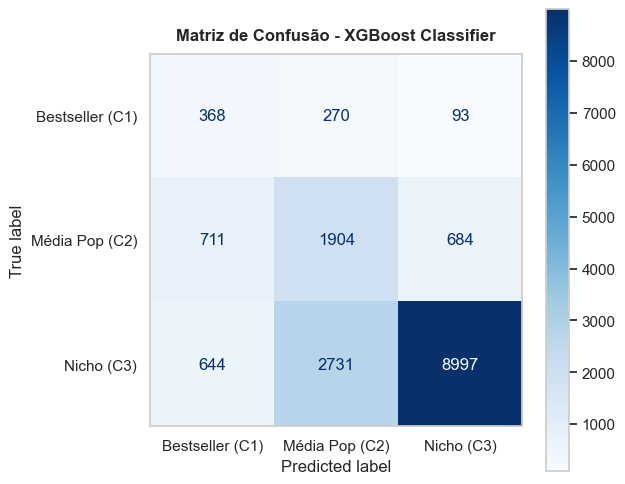

In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Computação e renderização do mapa de calor de confusão
cm = confusion_matrix(y_test_xgb, previsoes_xgb)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, 
    display_labels=['Bestseller (C1)', 'Média Pop (C2)', 'Nicho (C3)']
)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title("Matriz de Confusão - XGBoost Classifier", fontsize=12, fontweight='bold', pad=10)
plt.grid(False)
plt.show()

## 5. Relevância Estrutural de Atributos (*Feature Importance*)

Diferente de modelos lineares que expressam coeficientes direcionais (positivos ou negativos), modelos baseados em comitês de árvores extraem a relevância dos atributos com base no ganho de informação (*Gain*). O gráfico abaixo mapeia a contribuição relativa de cada metadado de pré-lançamento para a redução da impureza (entropia) global nos nós de decisão do comitê.

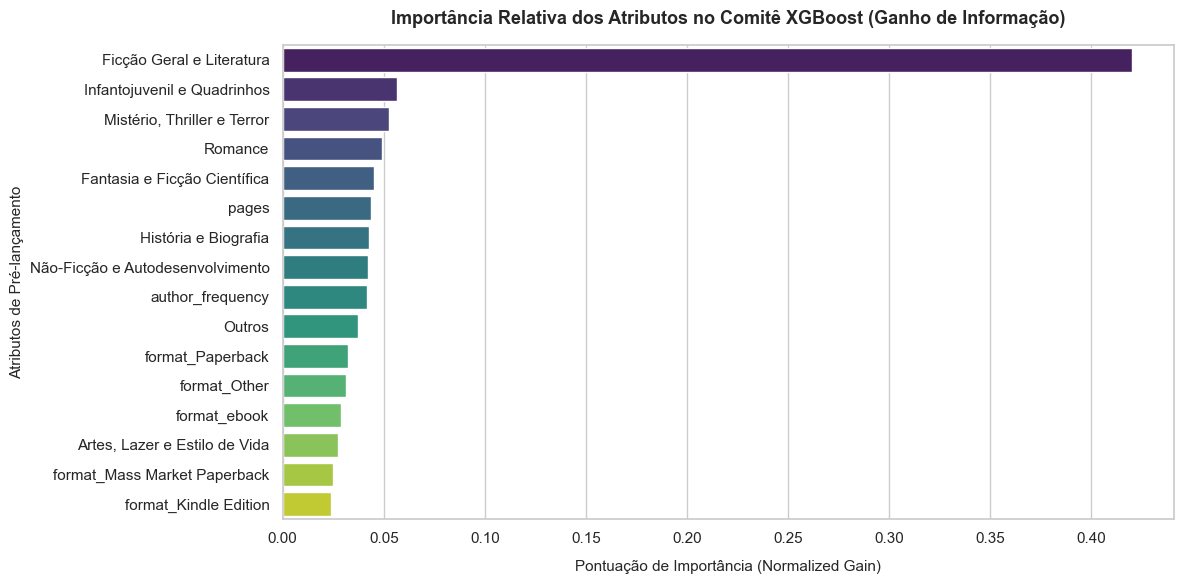

In [18]:
import seaborn as sns

# Extração da importância nativa dos atributos (Métrica padrão: Gain)
importancias = melhor_xgb.feature_importances_

# Estruturação e ordenação dos dados para exibição gráfica
df_importancia = pd.DataFrame({
    'Atributo': x_train.columns,
    'Importância Relativa': importancias
}).sort_values(by='Importância Relativa', ascending=False)

# Renderização do gráfico de barras horizontais em conformidade com as APIs estáveis do Seaborn
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

sns.barplot(
    x='Importância Relativa', 
    y='Atributo', 
    hue='Atributo',
    legend=False,
    data=df_importancia, 
    palette='viridis'  # Gradação profissional para indicar intensidade de relevância
)

plt.title('Importância Relativa dos Atributos no Comitê XGBoost (Ganho de Informação)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Pontuação de Importância (Normalized Gain)', fontsize=11, labelpad=10)
plt.ylabel('Atributos de Pré-lançamento', fontsize=11)
plt.tight_layout()
plt.show()

## 6. Serialização e Persistência do Artefato

Após a validação estatística do modelo de Boosting, o estimador final calibrado e otimizado é serializado em formato binário `.pkl`. Esse procedimento garante a integridade matemática dos parâmetros aprendidos e possibilita sua posterior carga em ambiente produtivo para inferências em tempo real na aplicação final.

In [19]:
import joblib
import os

# Definição e estruturação do diretório físico para armazenamento
models_dir = os.path.abspath(os.path.join(os.getcwd(), "..", "..", "Machine Learning", "models"))
os.makedirs(models_dir, exist_ok=True)

# Salvamento do modelo final do XGBoost
joblib.dump(melhor_xgb, os.path.join(models_dir, "xgb_popularidade.pkl"))
print("Artefato binário do XGBoost exportado e persistido com sucesso para produção!")

Artefato binário do XGBoost exportado e persistido com sucesso para produção!
